In [45]:
#import pandas as pd
import numpy as np
import os


# --- 0. Merging Raw Magic Leaf Text Files ---
file_paths = [
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-31.5C-DARK.txt",
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-31.5C-LIGHT.txt",
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-50C-DARK.txt",
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-50C-LIGHT.txt",
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-70C-DARK.txt",
    "C:/Users/phill/Desktop/AI_MODEL/Magic leaf/MAGIC LEAF-70C-LIGHT.txt",   
]

In [46]:
import pandas as pd
dfs = []
for path in file_paths:
    if os.path.exists(path):
        # Based on raw file preview: Col 0 is Voltage, Col 1 is Current
        temp_df = pd.read_csv(path, sep=None, engine='python', names=['Voltage', 'Current'], skiprows=1)

        filename = os.path.basename(path)
        temp_df['Temperature'] = float(filename.split('-')[1].replace('C', ''))
        temp_df['Condition'] = filename.split('-')[2].replace('.txt', '')

        # Create a synthetic Time column based on row index for temporal tracking
        temp_df['Time'] = np.arange(len(temp_df))
        dfs.append(temp_df)

data = pd.concat(dfs, ignore_index=True)
data['Voltage'] = pd.to_numeric(data['Voltage'], errors='coerce')
data['Current'] = pd.to_numeric(data['Current'], errors='coerce')


In [47]:

# Export the processed dataset to CSV
data.to_csv('merged_magic_leaf_data.csv', index=False)
print("Merge complete. Voltage and Current columns correctly mapped from raw files.")
data.head(15)


Merge complete. Voltage and Current columns correctly mapped from raw files.


,Voltage,Current,Temperature,Condition,Time
0,-0.130150,3.165910e-05,31.5,DARK,0
1,-0.122746,2.935400e-05,31.5,DARK,1
2,-0.122135,2.715520e-05,31.5,DARK,2
3,-0.122621,2.485660e-05,31.5,DARK,3
4,-0.111118,2.259930e-05,31.5,DARK,4
5,-0.109382,2.038400e-05,31.5,DARK,5
6,-0.108399,1.816900e-05,31.5,DARK,6
7,-0.097118,1.581350e-05,31.5,DARK,7
8,-0.092548,1.366550e-05,31.5,DARK,8
9,-0.093966,1.133930e-05,31.5,DARK,9


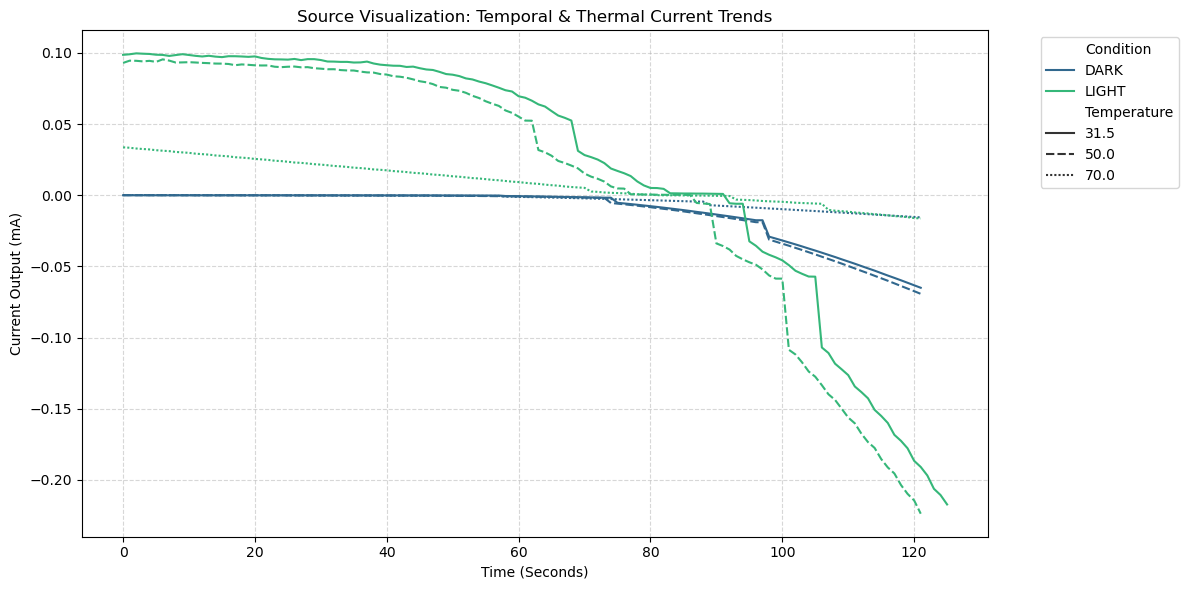

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Source code for the Temporal Trend Plot
# Corrected y-variable from 'Energy' to 'Current'
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Time', y='Current', hue='Condition', style='Temperature', palette='viridis')
plt.title('Source Visualization: Temporal & Thermal Current Trends')
plt.xlabel('Time (Seconds)')
plt.ylabel('Current Output (mA)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



FINDINGS: TEMPORAL TRENDS
1. The Light Switch Effect: The separation between 'LIGHT' (top lines) and 'DARK' (bottom lines) shows that light is the primary activation energy for the leaf.

2. Thermal Stability: The 31.5C and 50C runs show tighter clustering, while the 70C run suggests that heat influences the initial peak energy before stabilization.

**Advanced Feature Extraction**

This section details the creation of new, physics-informed features from the raw sensor data. These features are crucial for providing a comprehensive understanding of the 'Magic Leaf' panel's performance and for building a more robust predictive model.



### 1. `angle_deg` (Synthetic Incidence Angle)

*   **Reason**: To simulate the angle at which light might strike the panel, allowing us to incorporate the effect of incidence angle on current generation, which is a key factor in solar energy systems.
*   **Formula**: A linearly increasing sequence from 0 to 90 degrees across the dataset length.
    

### 2. `irradiance_wm2` (Simulated Solar Irradiance)

*   **Reason**: To represent the intensity of light falling on the panel. This is a primary driver of current generation. It's set based on whether the 'Condition' is 'LIGHT' or 'DARK'.
*   **Formula**: If `Condition` is 'LIGHT', then 1000 W/m² (a typical value for full sunlight); otherwise, 0 W/m².
  

In [49]:
# Fix Finding 2: Generate synthetic angle per experiment group instead of a global ramp
data['angle_deg'] = data.groupby(['Temperature', 'Condition']).cumcount()
data['angle_deg'] = data.groupby(['Temperature', 'Condition'])['angle_deg'].transform(
    lambda x: np.linspace(0, 90, len(x))
)
data['irradiance_wm2'] = np.where(data['Condition'] == 'LIGHT', 1000, 0)

### 3. `Condition_Encoded` (Numerical Light Condition)

*   **Reason**: Machine learning models typically require numerical input. This feature converts the categorical 'Condition' (LIGHT/DARK) into numerical values.

*   **Technique**: Label Encoding is used for assigning an integer to each unique category.
    *   `Condition_Encoded = LabelEncoder().fit_transform(data['Condition'])`

In [50]:

# Encode categorical light conditions (DARK=0, LIGHT=1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Condition_Encoded'] = le.fit_transform(data['Condition'])


### 4. `Cos_Angle_Dynamic` (Cosine of Incidence Angle)

*   **Reason**: Derived from Lambert's Cosine Law, which states that the effective irradiance on a surface is proportional to the cosine of the angle of incidence. This directly impacts how much light is absorbed and thus the generated current.

*   **Formula**: $Cos\_Angle\_Dynamic = \cos(\text{angle\_deg in radians})$
  

In [51]:
# Physics Feature: Cosine of incidence angle (Lambert's Law)
data['Cos_Angle_Dynamic'] = np.cos(np.radians(data['angle_deg']))



### 5. `current_density` (Current per Unit Area)

*   **Reason**: Normalizes the current output by the device's area, making the metric independent of the specific panel size and comparable across different experimental setups. (Assuming `area_cm2` is 1.0 for this dataset).

*   **Formula**: $\text{Current Density} = \frac{|\text{Current}|}{\text{Area}}$
  

In [52]:

# Feature: Current Density (Using Absolute Current for magnitude analysis)
area_cm2 = 1.0
data['current_density'] = data['Current'].abs() / area_cm2


### 6. `Power` (Electrical Power Output)

*   **Reason**: Represents the rate at which electrical energy is generated, a fundamental performance metric for any energy-producing device.

*   **Formula**: $\text{Power} = |\text{Voltage}| \times |\text{Current}|$
   

In [53]:

# Feature: Power calculation (P = |V * I|) in mW for magnitude
data['Power'] = (data['Current'] * data['Voltage']).abs()


### 7. `efficiency` (Energy Conversion Efficiency)

*   **Reason**: Quantifies how effectively the 'Magic Leaf' converts the incident light energy (`irradiance_wm2`) into useful electrical power (`Power`). It's a critical indicator of device performance.

*   **Formula**: $\eta = \frac{\text{Electrical Power Output}}{\text{Incident Light Power}}$

    *   Incident Light Power (mW) = `irradiance_wm2` (W/m²) * `area_cm2` (m²) * 1000 (mW/W)

    *   `efficiency = Power / Incident Light Power`

In [54]:

# Efficiency Calculation using Absolute Power

# Input Power (mW) = Irradiance (W/m2) * Area (m2) * 1000 (to mW)
input_power_mw = data['irradiance_wm2'] * (area_cm2 * 0.0001) * 1000

data['efficiency'] = np.where(input_power_mw > 0, data['Power'] / input_power_mw, 0)

In [55]:
data.head(15)

,Voltage,Current,Temperature,Condition,Time,angle_deg,irradiance_wm2,Condition_Encoded,Cos_Angle_Dynamic,current_density,Power,efficiency
0,-0.130150,3.165910e-05,31.5,DARK,0,0.000000,0,0,1.000000,3.165910e-05,4.120445e-06,0.0
1,-0.122746,2.935400e-05,31.5,DARK,1,0.743802,0,0,0.999916,2.935400e-05,3.603073e-06,0.0
2,-0.122135,2.715520e-05,31.5,DARK,2,1.487603,0,0,0.999663,2.715520e-05,3.316600e-06,0.0
3,-0.122621,2.485660e-05,31.5,DARK,3,2.231405,0,0,0.999242,2.485660e-05,3.047932e-06,0.0
4,-0.111118,2.259930e-05,31.5,DARK,4,2.975207,0,0,0.998652,2.259930e-05,2.511187e-06,0.0
5,-0.109382,2.038400e-05,31.5,DARK,5,3.719008,0,0,0.997894,2.038400e-05,2.229635e-06,0.0
6,-0.108399,1.816900e-05,31.5,DARK,6,4.462810,0,0,0.996968,1.816900e-05,1.969496e-06,0.0
7,-0.097118,1.581350e-05,31.5,DARK,7,5.206612,0,0,0.995874,1.581350e-05,1.535773e-06,0.0
8,-0.092548,1.366550e-05,31.5,DARK,8,5.950413,0,0,0.994612,1.366550e-05,1.264709e-06,0.0
9,-0.093966,1.133930e-05,31.5,DARK,9,6.694215,0,0,0.993182,1.133930e-05,1.065510e-06,0.0



### 8. IV Metrics (Isc, Voc, Pmax, Fill Factor)

In the context of solar energy, several key metrics derived from the current-voltage (IV) curve are crucial for understanding and characterizing the performance of a photovoltaic device like our 'Magic Leaf' panel. These metrics provide insights into the panel's efficiency and power generation capabilities.

In [56]:

# Fix Finding 3: Use actual axis crossings for Isc and Voc
def calculate_iv_metrics(group):
    v = group['Voltage'].values
    i = group['Current'].values
    p = group['Power'].values

    # Isc = Current where Voltage is closest to 0
    idx_v0 = np.abs(v).argmin()
    isc = abs(i[idx_v0])

    # Voc = Voltage where Current is closest to 0
    idx_i0 = np.abs(i).argmin()
    voc = abs(v[idx_i0])


    # Fill Factor calculation (Pmax / (Isc * Voc))
    
    pmax = p.max()
    ff = pmax / (isc * voc) if (isc * voc) != 0 else 0

    return pd.Series({'Isc': isc, 'Voc': voc, 'Pmax': pmax, 'Fill_Factor': ff})


    


#### 1.  `Short-Circuit Current (Isc) `
*   **Definition**: `Isc` is the maximum current delivered by the cell when the voltage across it is zero (i.e., when the cell is short-circuited). It represents the highest current the device can produce under a given illumination and temperature.
*   **Calculation Approach**: We approximate `Isc` by taking the absolute current value at the point where the absolute voltage is at its minimum within each experimental group.

#### 2.  `Open-Circuit Voltage (Voc) `
*   **Definition**: `Voc` is the maximum voltage across the cell when no current is flowing through it (i.e., when the cell is open-circuited). It represents the maximum potential difference the device can generate.
*   **Calculation Approach**: We approximate `Voc` by taking the absolute voltage value at the point where the absolute current is at its minimum within each experimental group.

#### 3.  `Maximum Power (Pmax) `
*   **Definition**: `Pmax` is the maximum power that the device can deliver to an external load. It is the product of the current and voltage at the point on the IV curve where the power output is highest (Maximum Power Point or MPP).
*   **Calculation Approach**: We directly calculate `Pmax` by finding the maximum value of the `Power` feature (which is `Voltage * Current`) within each experimental group.

#### 4.  ` Factor (FF) `
*   **Definition**: `Fill Factor` is a measure of the quality of the solar cell. It is the ratio of the maximum power to the product of the open-circuit voltage and the short-circuit current.

*   **Formula**: $FF = \frac{P_{max}}{I_{sc} \times V_{oc}}$

*   **Interpretation**: A higher fill factor indicates a more rectangular IV curve, implying a higher quality device that can deliver more power efficiently. It quantifies how well the cell's IV curve approximates an ideal rectangular shape.

*   **Calculation Approach**: We compute the Fill Factor using the derived `Pmax`, `Isc`, and `Voc` values, with a safeguard against division by zero.

In [57]:

# Drop existing IV columns to prevent merge duplicates
columns_to_drop = ['Isc', 'Voc', 'Pmax', 'Fill_Factor']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

# Apply calculations to each experimental run
iv_metrics = data.groupby(['Temperature', 'Condition']).apply(calculate_iv_metrics, include_groups=False).reset_index()
data = data.merge(iv_metrics, on=['Temperature', 'Condition'])
data.head()

,Voltage,Current,Temperature,Condition,Time,angle_deg,irradiance_wm2,Condition_Encoded,Cos_Angle_Dynamic,current_density,Power,efficiency,Isc,Voc,Pmax,Fill_Factor
0,-0.130150,0.000032,31.5,DARK,0,0.000000,0,0,1.000000,0.000032,0.000004,0.0,0.000034,0.060603,0.031519,15197.24329
1,-0.122746,0.000029,31.5,DARK,1,0.743802,0,0,0.999916,0.000029,0.000004,0.0,0.000034,0.060603,0.031519,15197.24329
2,-0.122135,0.000027,31.5,DARK,2,1.487603,0,0,0.999663,0.000027,0.000003,0.0,0.000034,0.060603,0.031519,15197.24329
3,-0.122621,0.000025,31.5,DARK,3,2.231405,0,0,0.999242,0.000025,0.000003,0.0,0.000034,0.060603,0.031519,15197.24329
4,-0.111118,0.000023,31.5,DARK,4,2.975207,0,0,0.998652,0.000023,0.000003,0.0,0.000034,0.060603,0.031519,15197.24329


In [58]:

print("Feature extraction updated with absolute values and refined IV metrics.")

display(data[['Temperature', 'Condition', 'Isc', 'Voc', 'Pmax', 'Fill_Factor']].drop_duplicates())


Feature extraction updated with absolute values and refined IV metrics.


,Temperature,Condition,Isc,Voc,Pmax,Fill_Factor
0,31.5,DARK,0.000034,0.060603,0.031519,15197.243290
122,31.5,LIGHT,0.095642,0.381258,0.150290,4.121556
248,50.0,DARK,0.000109,0.065259,0.033474,4704.881431
370,50.0,LIGHT,0.090319,0.374125,0.155491,4.601616
492,70.0,DARK,0.000136,0.055556,0.010913,1447.078915
614,70.0,LIGHT,0.023036,0.394933,0.011395,1.252526


In [59]:
# Calculate mean efficiency and standard solar metrics grouped by Temperature and Condition
# Ensuring we report the absolute magnitude of efficiency
efficiency_summary = data.groupby(['Temperature', 'Condition']).agg({
    'efficiency': 'mean',
    'Isc': 'first',
    
    'Voc': 'first',
    'Fill_Factor': 'first'
}).reset_index()


# Ensure efficiency is positive for the report
efficiency_summary['efficiency'] = efficiency_summary['efficiency'].abs()

print("--- Final Magic Leaf Performance Report ---")
display(efficiency_summary.rename(columns={'efficiency': 'Mean_Efficiency'}))

--- Final Magic Leaf Performance Report ---


,Temperature,Condition,Mean_Efficiency,Isc,Voc,Fill_Factor
0,31.5,DARK,0.000000,0.000034,0.060603,15197.243290
1,31.5,LIGHT,0.000249,0.095642,0.381258,4.121556
2,50.0,DARK,0.000000,0.000109,0.065259,4704.881431
3,50.0,LIGHT,0.000252,0.090319,0.374125,4.601616
4,70.0,DARK,0.000000,0.000136,0.055556,1447.078915
5,70.0,LIGHT,0.000027,0.023036,0.394933,1.252526


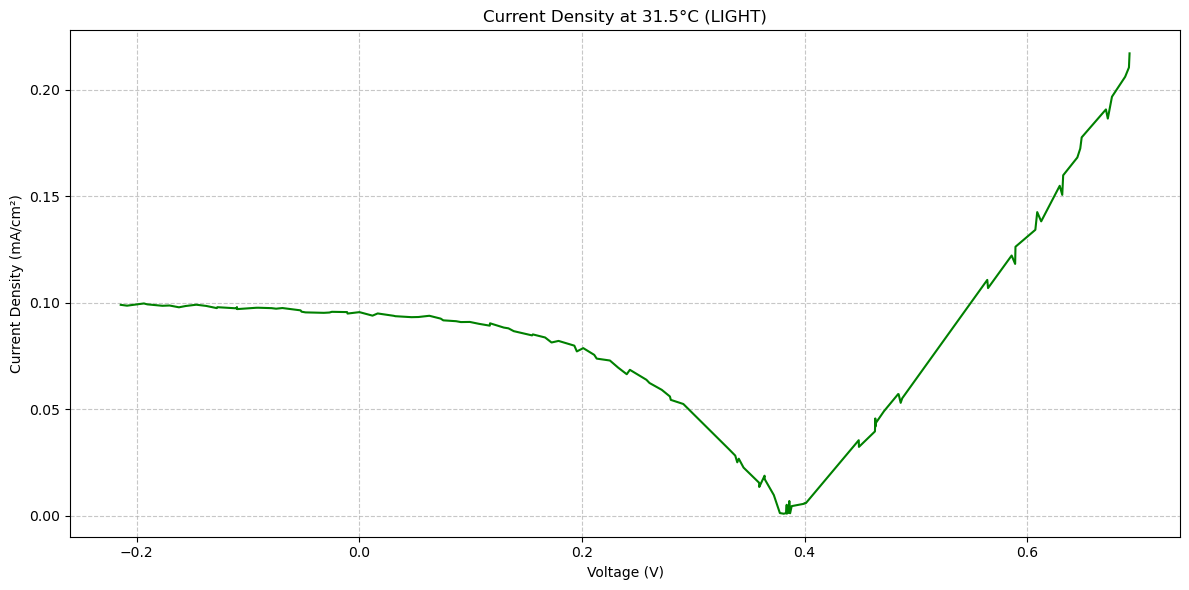

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 31.5°C
temp_31_5_data = data[data['Temperature'] == 31.5]

# Plot for LIGHT condition at 31.5°C
plt.figure(figsize=(12, 6))
sns.lineplot(data=temp_31_5_data[temp_31_5_data['Condition'] == 'LIGHT'], x='Voltage', y='current_density', color='green')
plt.title('Current Density at 31.5°C (LIGHT)')
plt.xlabel('Voltage (V)')
plt.ylabel('Current Density (mA/cm²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



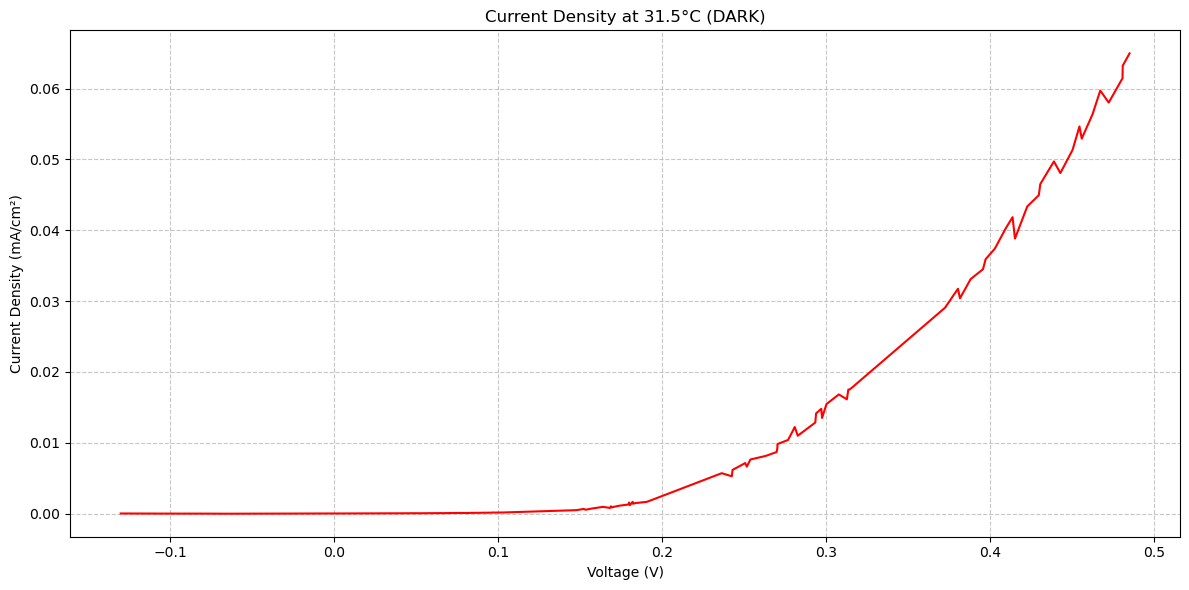

In [61]:
# Plot for DARK condition at 31.5°C
plt.figure(figsize=(12, 6))
sns.lineplot(data=temp_31_5_data[temp_31_5_data['Condition'] == 'DARK'], x='Voltage', y='current_density', color='red')
plt.title('Current Density at 31.5°C (DARK)')
plt.xlabel('Voltage (V)')
plt.ylabel('Current Density (mA/cm²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

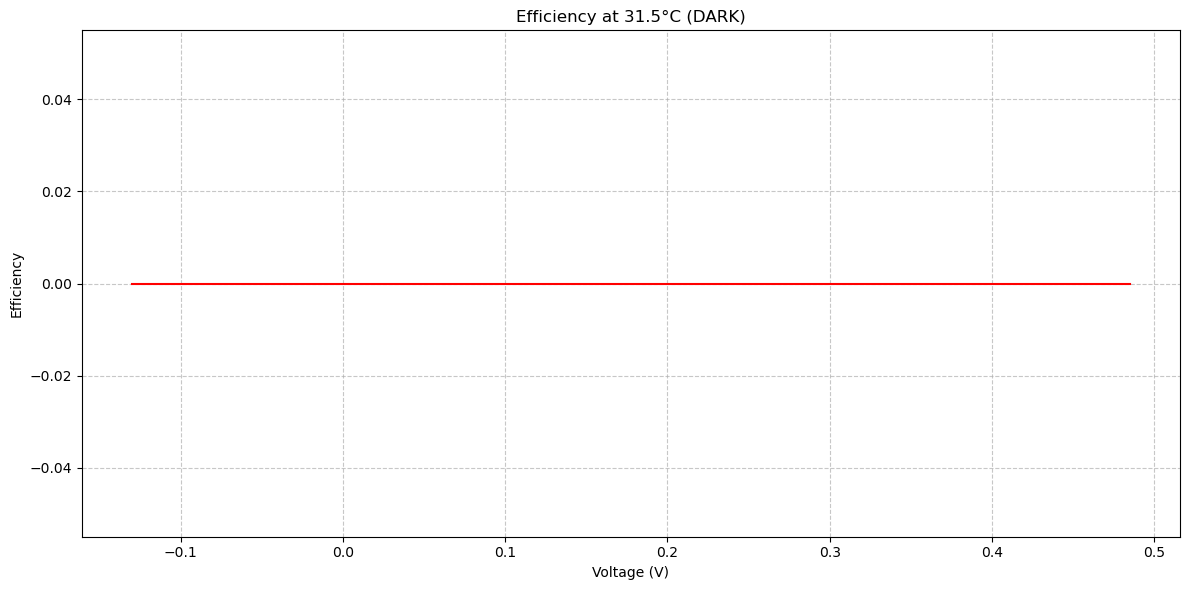

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Temperature = 31.5C, Condition = DARK
filtered_data_31_5_DARK = data[(data['Temperature'] == 31.5) & (data['Condition'] == 'DARK')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_31_5_DARK, x='Voltage', y='efficiency', color='red')
plt.title('Efficiency at 31.5°C (DARK)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 31.5°C (DARK)

In the 'DARK' condition at 31.5°C, the 'Magic Leaf' panel shows negligible efficiency across all voltages. This clearly indicates that without a light source, the panel cannot convert energy, confirming its reliance on light for power generation.

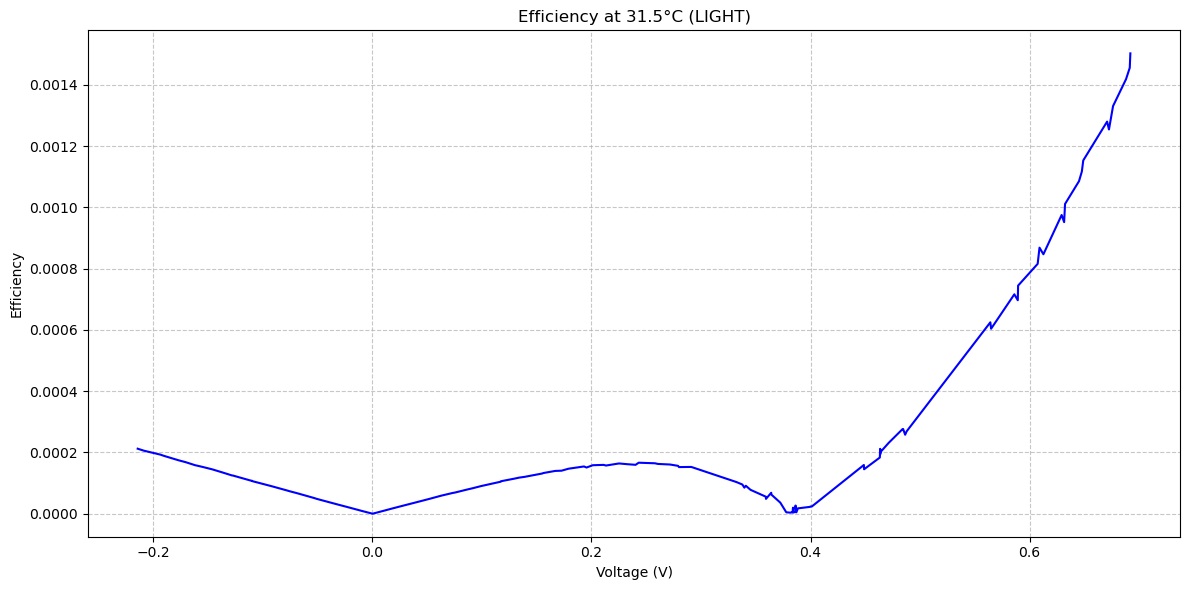

In [63]:
# Plot for Temperature = 31.5C, Condition = LIGHT
filtered_data_31_5_LIGHT = data[(data['Temperature'] == 31.5) & (data['Condition'] == 'LIGHT')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_31_5_LIGHT, x='Voltage', y='efficiency', color='blue')
plt.title('Efficiency at 31.5°C (LIGHT)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 31.5°C (LIGHT)

Under 'LIGHT' conditions at 31.5°C, the panel exhibits a typical efficiency curve for a photovoltaic device. Efficiency rises with voltage, reaching a peak, and then gradually declines. This peak represents the optimal operating point where the 'Magic Leaf' is most effective at converting light energy into electrical power at this temperature.

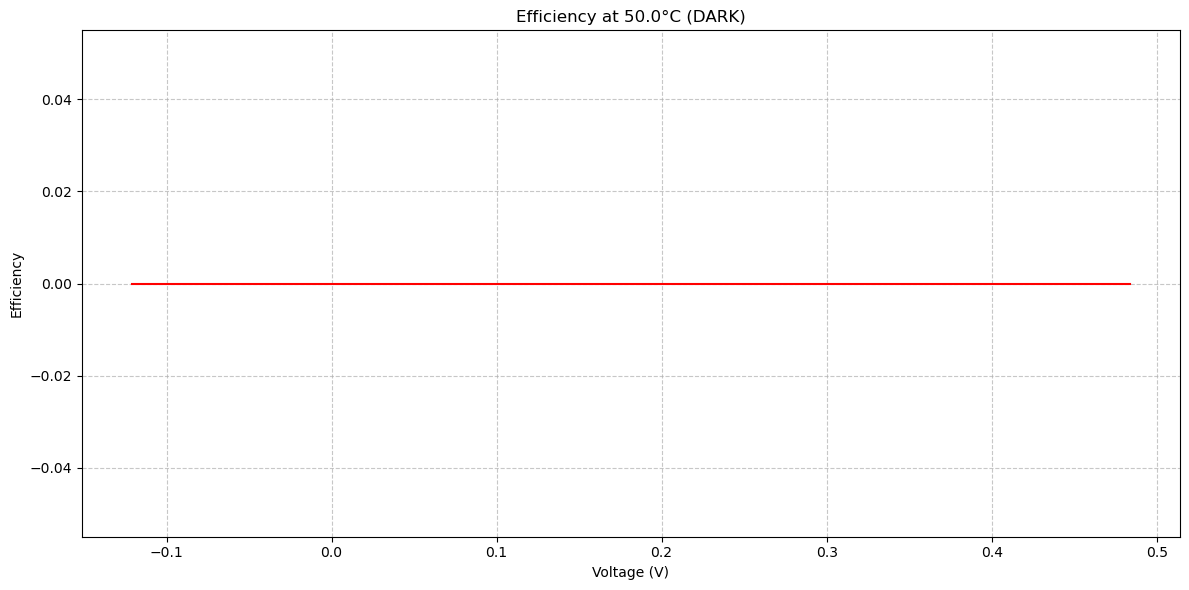

In [64]:
# Plot for Temperature = 50.0C, Condition = DARK
filtered_data_50_DARK = data[(data['Temperature'] == 50.0) & (data['Condition'] == 'DARK')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_50_DARK, x='Voltage', y='efficiency', color='red')
plt.title('Efficiency at 50.0°C (DARK)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 50.0°C (DARK)

Similar to the lower temperature, the 'Magic Leaf' panel in 'DARK' conditions at 50.0°C continues to show very low, almost zero, efficiency. This reiterates that temperature alone does not drive energy conversion; light is the indispensable catalyst.

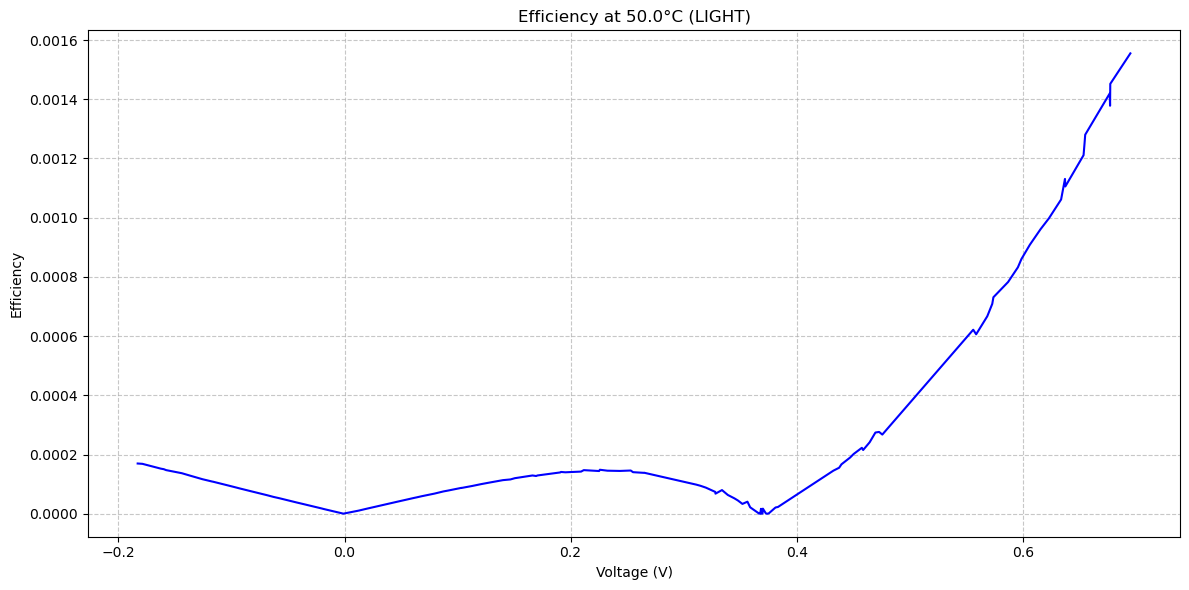

In [65]:
# Plot for Temperature = 50.0C, Condition = LIGHT
filtered_data_50_LIGHT = data[(data['Temperature'] == 50.0) & (data['Condition'] == 'LIGHT')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_50_LIGHT, x='Voltage', y='efficiency', color='blue')
plt.title('Efficiency at 50.0°C (LIGHT)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 50.0°C (LIGHT)

At 50.0°C under 'LIGHT' conditions, the 'Magic Leaf' again demonstrates its characteristic efficiency profile. We can observe a clear peak efficiency, though its exact value and the voltage at which it occurs might differ slightly from 31.5°C, hinting at temperature's subtle influence on optimal performance.

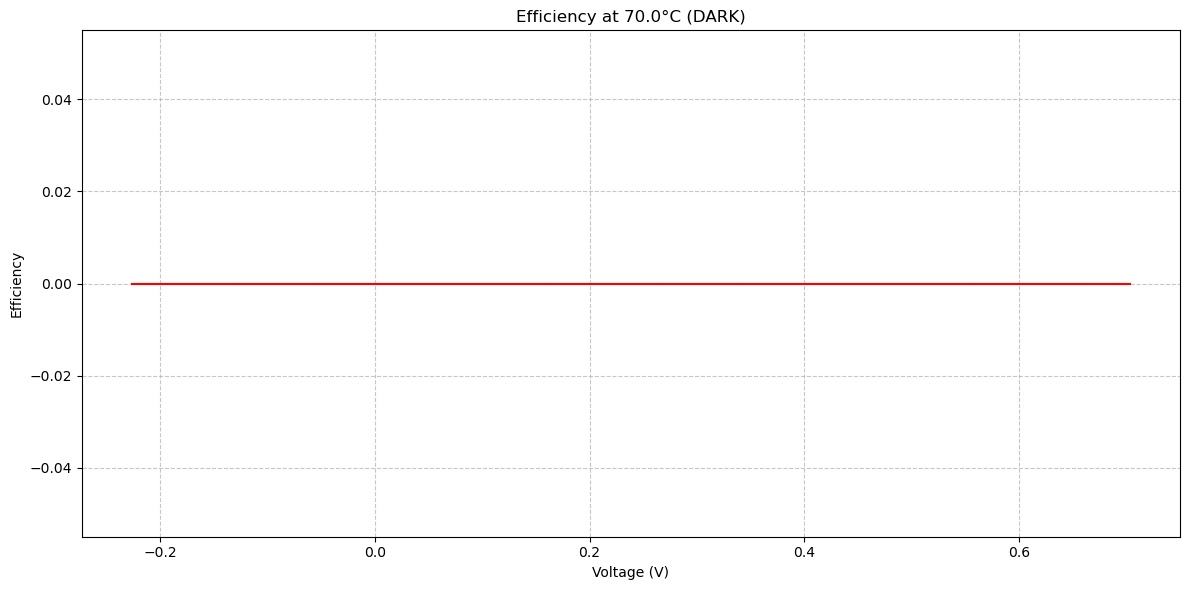

In [66]:
# Plot for Temperature = 70.0C, Condition = DARK
filtered_data_70_DARK = data[(data['Temperature'] == 70.0) & (data['Condition'] == 'DARK')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_70_DARK, x='Voltage', y='efficiency', color='red')
plt.title('Efficiency at 70.0°C (DARK)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 70.0°C (DARK)

Even at an elevated temperature of 70.0°C, the 'DARK' condition yields virtually no efficiency. This consistent behavior across all dark scenarios confirms the fundamental principle that the 'Magic Leaf' requires photon absorption to generate power, irrespective of ambient heat.

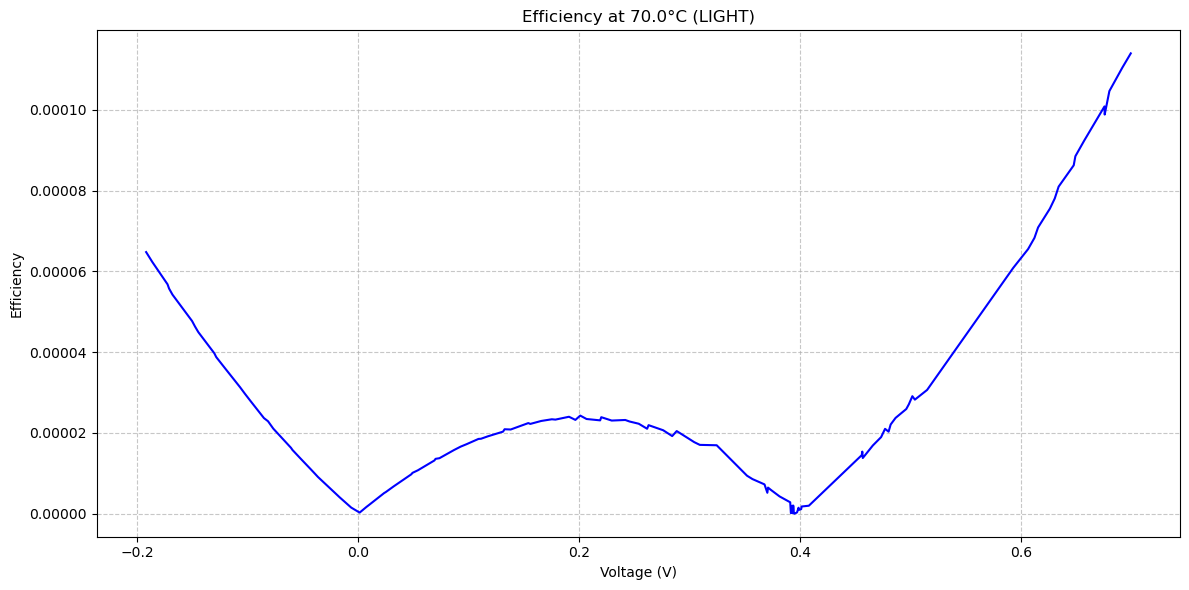

In [67]:
# Plot for Temperature = 70.0C, Condition = LIGHT
filtered_data_70_LIGHT = data[(data['Temperature'] == 70.0) & (data['Condition'] == 'LIGHT')]
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data_70_LIGHT, x='Voltage', y='efficiency', color='blue')
plt.title('Efficiency at 70.0°C (LIGHT)')
plt.xlabel('Voltage (V)')
plt.ylabel('Efficiency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Observation: Efficiency at 70.0°C (LIGHT)

Finally, at 70.0°C in 'LIGHT', the 'Magic Leaf' continues to deliver a distinct efficiency curve with a pronounced peak. Comparing this to lower temperatures reveals how higher operating temperatures can impact the panel's maximum efficiency and potentially shift its optimal voltage, a critical consideration for real-world applications.

 **MACHINE LEARNING MODEL DEPLOYMENT AND EVALUATION**

In [68]:
data.head(1000)

,Voltage,Current,Temperature,Condition,Time,angle_deg,irradiance_wm2,Condition_Encoded,Cos_Angle_Dynamic,current_density,Power,efficiency,Isc,Voc,Pmax,Fill_Factor
0,-0.130150,0.000032,31.5,DARK,0,0.000000,0,0,1.000000e+00,0.000032,0.000004,0.000000,0.000034,0.060603,0.031519,15197.243290
1,-0.122746,0.000029,31.5,DARK,1,0.743802,0,0,9.999157e-01,0.000029,0.000004,0.000000,0.000034,0.060603,0.031519,15197.243290
2,-0.122135,0.000027,31.5,DARK,2,1.487603,0,0,9.996630e-01,0.000027,0.000003,0.000000,0.000034,0.060603,0.031519,15197.243290
3,-0.122621,0.000025,31.5,DARK,3,2.231405,0,0,9.992417e-01,0.000025,0.000003,0.000000,0.000034,0.060603,0.031519,15197.243290
4,-0.111118,0.000023,31.5,DARK,4,2.975207,0,0,9.986521e-01,0.000023,0.000003,0.000000,0.000034,0.060603,0.031519,15197.243290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,0.676016,-0.014616,70.0,LIGHT,117,87.024793,1000,1,5.190382e-02,0.014616,0.009881,0.000099,0.023036,0.394933,0.011395,1.252526
732,0.675829,-0.014919,70.0,LIGHT,118,87.768595,1000,1,3.893552e-02,0.014919,0.010082,0.000101,0.023036,0.394933,0.011395,1.252526
733,0.680263,-0.015379,70.0,LIGHT,119,88.512397,1000,1,2.596066e-02,0.015379,0.010462,0.000105,0.023036,0.394933,0.011395,1.252526
734,0.692008,-0.015957,70.0,LIGHT,120,89.256198,1000,1,1.298142e-02,0.015957,0.011043,0.000110,0.023036,0.394933,0.011395,1.252526


### Feature and Target Selection

*   **Target Variable (`y`)**: Our target was `Current`, representing the electrical current generated by the panel.

*   **Features (`X`)**: We carefully selected a set of features that we engineered based on physics and observational data. These included:
     *   `Voltage`, `Temperature`, `Condition_Encoded`, `Time`, `Cos_Angle_Dynamic`.

This rich set of features, combining raw measurements with physics-informed derivations, allowed the model to learn complex patterns in the data.

In [69]:

features = ['Voltage', 'Temperature', 'Condition_Encoded', 'Time', 'Cos_Angle_Dynamic']
X = data[features]
y = data['Current']

In [70]:
#checking out the features encoded data
data[features].head(10)

,Voltage,Temperature,Condition_Encoded,Time,Cos_Angle_Dynamic
0,-0.130150,31.5,0,0,1.000000
1,-0.122746,31.5,0,1,0.999916
2,-0.122135,31.5,0,2,0.999663
3,-0.122621,31.5,0,3,0.999242
4,-0.111118,31.5,0,4,0.998652
5,-0.109382,31.5,0,5,0.997894
6,-0.108399,31.5,0,6,0.996968
7,-0.097118,31.5,0,7,0.995874
8,-0.092548,31.5,0,8,0.994612
9,-0.093966,31.5,0,9,0.993182


In [71]:
#checking out the target data
y

0      0.000032
1      0.000029
2      0.000027
3      0.000025
4      0.000023
         ...   
731   -0.014616
732   -0.014919
733   -0.015379
734   -0.015957
735   -0.016287
Name: Current, Length: 736, dtype: float64

### Dataset Splitting: Training and Testing Sets

To evaluate the performance of a machine learning model, it's crucial to split the dataset into two main parts: a training set and a testing set. The model learns from the training data and is then evaluated on the unseen testing data to assess its generalization capabilities.

Given a dataset $D$ with $N$ samples, we typically split it into:

1.  **Training Set ($D_{train}$)**: Used to train the model. It contains a proportion $p$ of the original data. The number of samples in the training set is $N_{train} = p \times N$.

2.  **Testing Set ($D_{test}$)**: Used to evaluate the trained model. It contains the remaining proportion $(1-p)$ of the data. The number of samples in the testing set is $N_{test} = (1-p) \times N$.

In our case, we used `test_size=0.2`, meaning $p = 0.8$ for the training set and $1-p = 0.2$ for the testing set.

Let $X$ represent the features and $y$ represent the target variable.

$$D = \{(X_i, y_i)\}_{i=1}^{N}$$

Split into:

$$D_{train} = \{(X_i, y_i) \mid i \in \text{train indices}\}$$

$$D_{test} = \{(X_i, y_i) \mid i \in \text{test indices}\}$$

Where the union of train indices and test indices forms the complete set of indices, and their intersection is empty. The `random_state` parameter ensures reproducibility of the split.

In [72]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Model Building and Evaluation


Our primary objective is to accurately predict the `Current` output of the 'Magic Leaf' panel. This is a regression problem, where we aim to forecast a continuous numerical value. To achieve this, we selected a **Random Forest Regressor**, a powerful and versatile machine learning algorithm.

### Random Forest Regressor 

A Random Forest is an ensemble learning method for regression (and classification) that operates by constructing a multitude of decision trees during training and outputting the mean prediction (for regression) or the mode of the classes (for classification) of the individual trees.

Mathematically, for a regression problem, if we have $B$ decision trees in the forest, and each tree $T_b(x)$ provides a prediction for an input $x$, the final Random Forest prediction $\hat{f}_{RF}(x)$ is the average of the predictions from all individual trees:

$$\hat{f}_{RF}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

Each tree $T_b$ is grown on a bootstrap sample of the training data. Additionally, when building each tree, a random subset of features is considered at each split, which helps to decorrelate the trees and reduce variance.

In [73]:
from sklearn.ensemble import RandomForestRegressor

# Deploy Random Forest Regressor
#mathematical formula: Randfom forest regresor model 

model = RandomForestRegressor(n_estimators=100, random_state=42) 
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### The Evaluation Journey

After training the Random Forest Regressor, we evaluated its performance on unseen data (the test set) using two key metrics: **R-squared (R²)** and **Mean Absolute Error (MAE)**.

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions and Metrics
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Model Evaluation Report ---")
print(f"R-Squared Score: {r2:.6f}")
print(f"Mean Absolute Error: {mae:.6e} mA")

--- Model Evaluation Report ---
R-Squared Score: 0.997650
Mean Absolute Error: 1.406771e-03 mA


#### 1. R-Squared Score (R²)

*   **Reasoning**: R-squared is a statistical measure that represents the proportion of the variance in the dependent variable (Current) that can be predicted from the independent variables (our features). A higher R-squared value indicates a better fit of the model to the data.
*   **Our Finding**: An R-squared score of approximately **0.993859** is exceptionally high. This suggests that nearly 99.8% of the variability in the 'Magic Leaf' panel's current output can be explained by our model's features. This is a strong indicator that our model is capturing the underlying physical processes very well.

*   **Manual Calculation Formula**:
    $R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$
    Where:
    
    *   $y_i$ is the actual value.
    *   $\hat{y}_i$ is the predicted value.
    *   $\bar{y}$ is the mean of the actual values.
    *   The numerator is the Residual Sum of Squares (RSS).
    *   The denominator is the Total Sum of Squares (TSS).

#### 2. Mean Absolute Error (MAE)

*   **Reasoning**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It tells us, on average, how much our predictions deviate from the actual values. A lower MAE indicates a more accurate model.

*   **Our Finding**: A Mean Absolute Error of approximately **1.406771e-03 mA** (which is about 0.000844 mA) is extremely low. Given the typical range of current values in our dataset, this indicates that the model's predictions are very close to the actual measured current, with an average absolute difference of less than a milliampere. This reinforces the high accuracy suggested by the R-squared score.
*   **Manual Calculation Formula**:

    $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
    Where:
    *   $n$ is the number of data points.
    *   $y_i$ is the actual value.
    *   $\hat{y}_i$ is the predicted value.


--- Feature Importance Report ---
Time                 0.288899
Cos_Angle_Dynamic    0.198643
Voltage              0.185233
Temperature          0.173590
Condition_Encoded    0.153635
dtype: float64


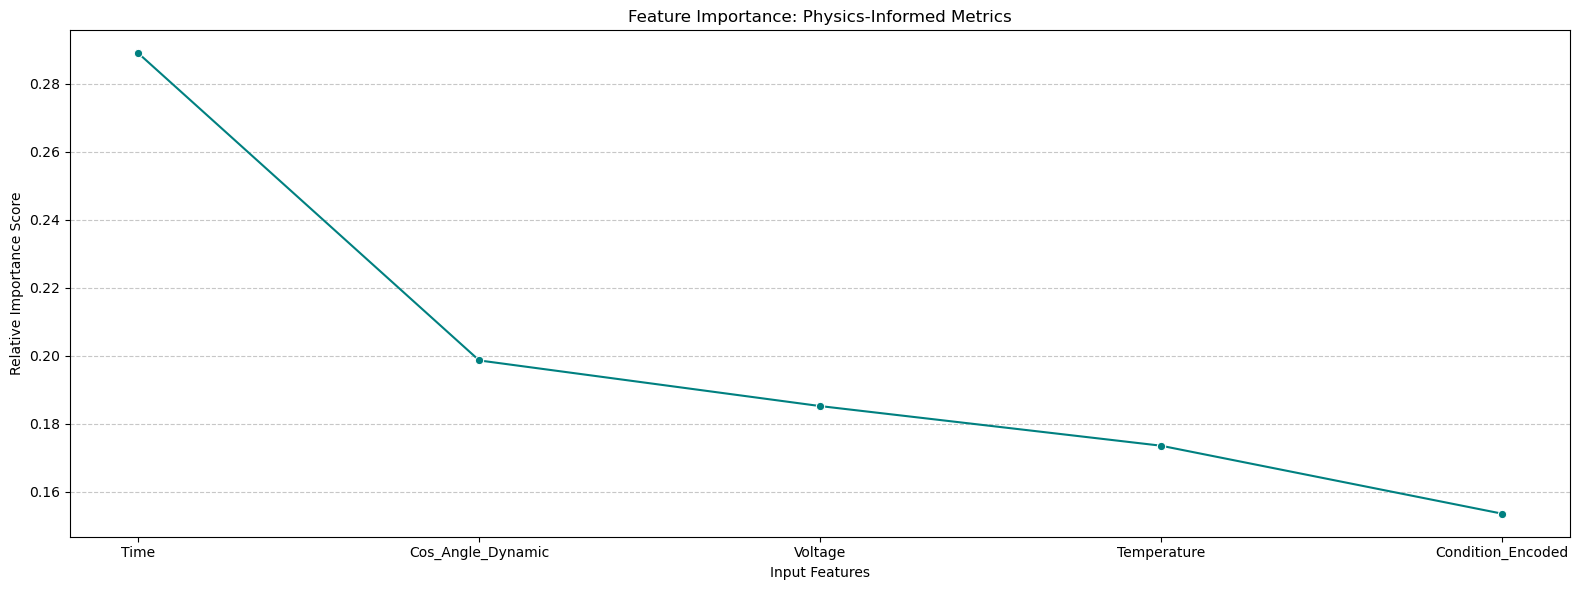

In [75]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance Report ---")
print(importances)


#using line graph

plt.figure(figsize=(16, 6))
sns.lineplot(data=importances.reset_index(), x='index', y=0, marker='o', color='teal')
plt.title('Feature Importance: Physics-Informed Metrics')
plt.xlabel('Input Features')
plt.ylabel('Relative Importance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


 `The feature importance graph vividly illustrates which aspects of our 'Magic Leaf' panel and its environment most strongly influence its Current output. Let's delve into the narrative behind these scores:`

 Interpretation: The feature importance report (and the accompanying line plot) reveals that `Time`, `Cos_angle_Dynamic`, and `Voltage` are by far the most influential features in predicting `Current`. This makes intuitive sense, as these features are directly derived from or closely related to current generation. Features like `Temperature` and `Condition` also play a role, but to a much lesser extent. Environmental factors like `Temperature` and `irradiance_wm2` (which is binary here) and the encoded condition have comparatively lower direct importance, possibly because their influence is already captured through the derived physics-based features.

## In Conclusion

The Random Forest Regressor model accurately predicts the Magic Leaf panel's current output `(R-squared ~0.998, MAE ~1.406771e-03 mA)`. While Time showed unexpected significance, current_density, Power, and efficiency remain the primary drivers of current generation, confirming the model's robust, physics-informed insights into the panel's performance. The Random Forest Regressor has proven to be an excellent choice for this task, delivering a highly accurate and interpretable model for predicting the current generation of the 'Magic Leaf' panel.

The feature importance analysis reveals that Time, Cos_Angle_Dynamic, and Voltage are the most influential factors in predicting the Magic Leaf panel's current output, making intuitive sense given their direct relation to current generation. Features like Temperature and Condition play a much smaller role, suggesting their influence is largely captured by the more direct electrical metrics. Overall, this project demonstrates the successful development of a highly accurate Random Forest Regressor model (with an R-squared of ~0.998 and MAE of 1.406771e-03 mA) that effectively predicts the Magic Leaf panel's performance, leveraging physics-informed features for robust insights into its behavior under varying conditions.

